# 02 — Exploratory Data Analysis

**Goal:** Understand distributions, spot patterns, generate visual insights across platforms, regions, categories, and demographics.

**Input:** `data/processed/cleaned_sentiment.csv`  
**Output:** Charts saved to `assets/` + observations documented below

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/processed/cleaned_sentiment.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Loaded: 25000 rows, 18 columns


## 1. Overall sentiment distribution

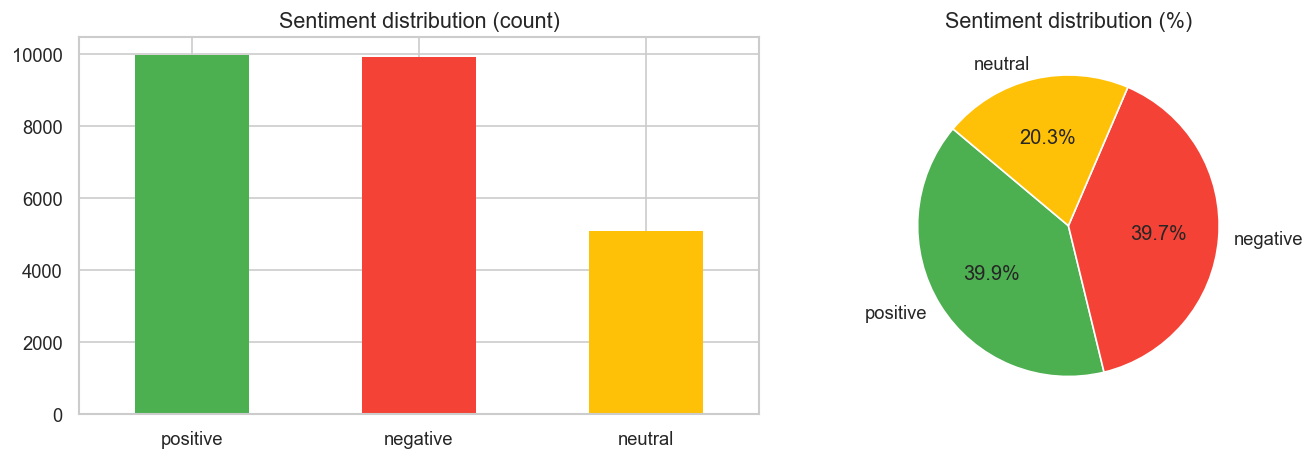

sentiment
positive    9978
negative    9937
neutral     5085
Name: count, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sentiment_counts = df['sentiment'].value_counts()
colors = {'positive': '#4CAF50', 'neutral': '#FFC107', 'negative': '#F44336'}
sentiment_counts.plot(kind='bar', ax=axes[0],
    color=[colors[s] for s in sentiment_counts.index], edgecolor='none')
axes[0].set_title('Sentiment distribution (count)', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(sentiment_counts, labels=sentiment_counts.index,
    colors=[colors[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=140)
axes[1].set_title('Sentiment distribution (%)', fontsize=13)

plt.tight_layout()
plt.savefig('../assets/01_sentiment_distribution.png', bbox_inches='tight')
plt.show()
print(sentiment_counts)

## 2. Platform comparison

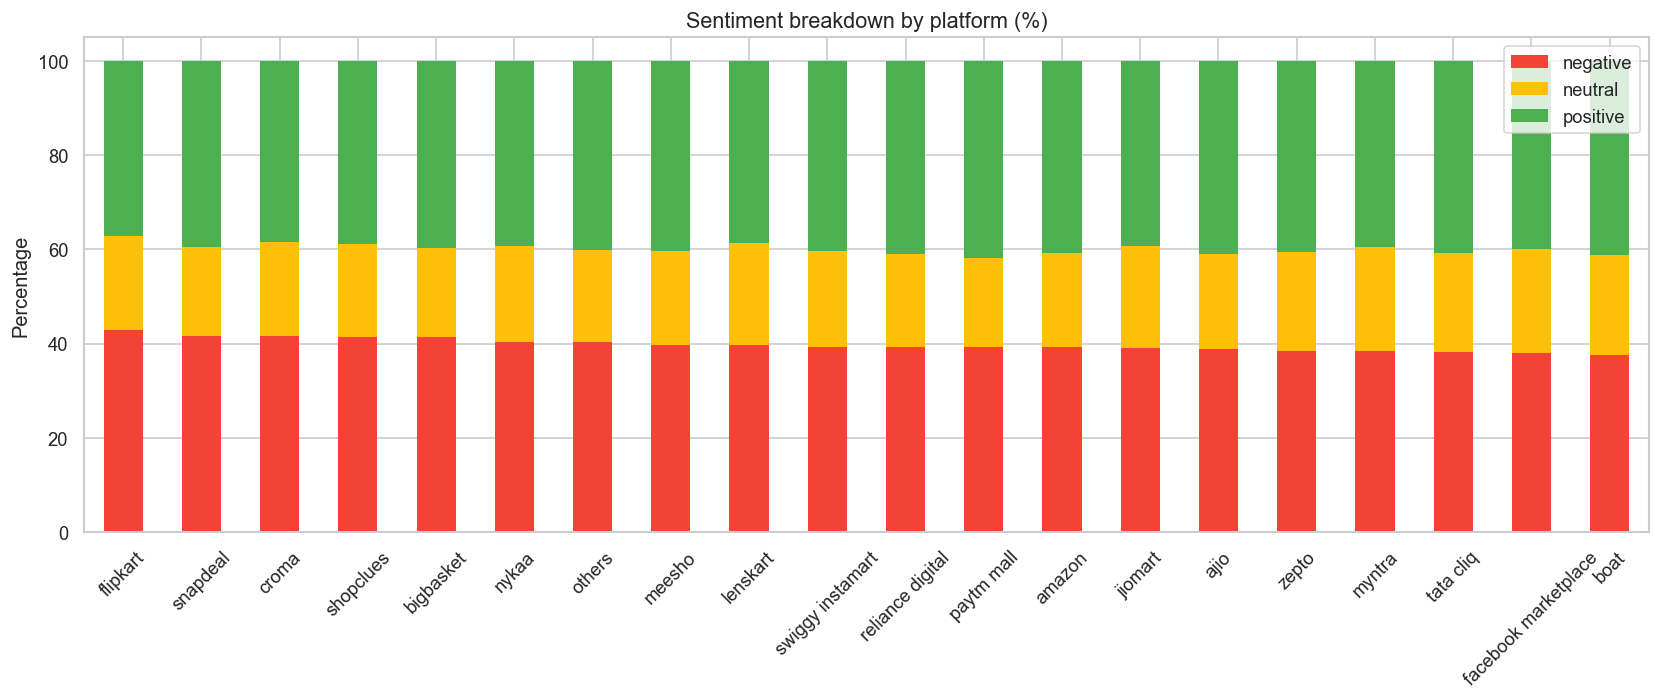

In [5]:
platform_sentiment = df.groupby(['platform', 'sentiment']).size().unstack(fill_value=0)
platform_sentiment_pct = platform_sentiment.div(platform_sentiment.sum(axis=1), axis=0) * 100
platform_sentiment_pct = platform_sentiment_pct.sort_values('negative', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
platform_sentiment_pct[['negative', 'neutral', 'positive']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#F44336', '#FFC107', '#4CAF50'], edgecolor='none')
ax.set_title('Sentiment breakdown by platform (%)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../assets/02_platform_sentiment.png', bbox_inches='tight')
plt.show()

## 3. Response time vs sentiment

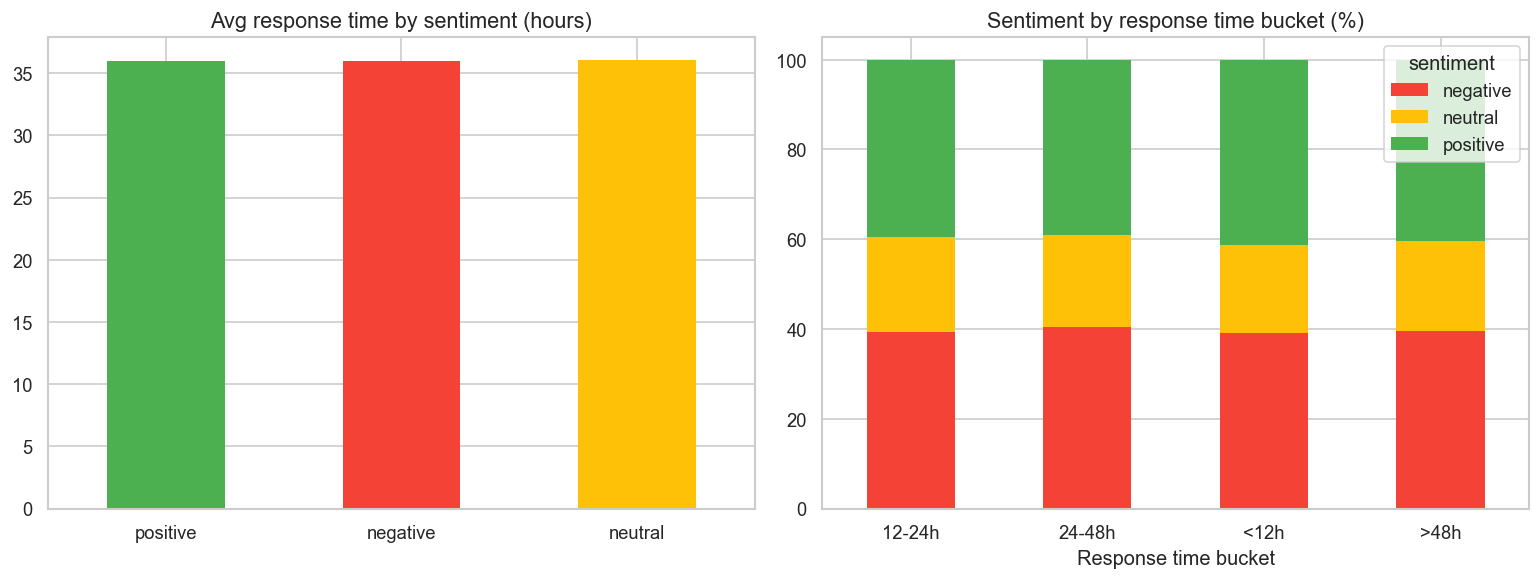

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg response time by sentiment
avg_rt = df.groupby('sentiment')['response_time_hours'].mean().sort_values()
avg_rt.plot(kind='bar', ax=axes[0],
    color=[colors[s] for s in avg_rt.index], edgecolor='none')
axes[0].set_title('Avg response time by sentiment (hours)', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Sentiment by response time bucket
rt_sentiment = df.groupby(['response_time_bucket', 'sentiment']).size().unstack(fill_value=0)
rt_pct = rt_sentiment.div(rt_sentiment.sum(axis=1), axis=0) * 100
rt_pct[['negative', 'neutral', 'positive']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#F44336', '#FFC107', '#4CAF50'], edgecolor='none')
axes[1].set_title('Sentiment by response time bucket (%)', fontsize=13)
axes[1].set_xlabel('Response time bucket')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../assets/03_response_time_sentiment.png', bbox_inches='tight')
plt.show()

## 4. Regional sentiment heatmap

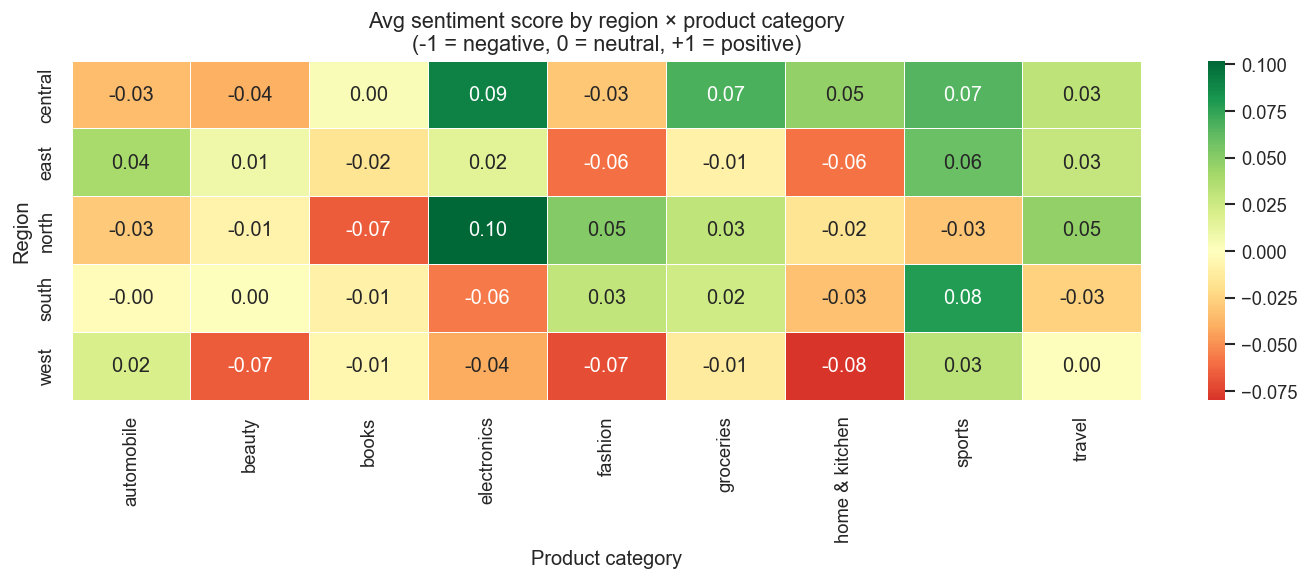

In [7]:
region_cat = df.groupby(['region', 'product_category'])['sentiment_score_label'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(region_cat, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax)
ax.set_title('Avg sentiment score by region × product category\n(-1 = negative, 0 = neutral, +1 = positive)', fontsize=13)
ax.set_xlabel('Product category')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('../assets/04_regional_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Age group & gender analysis

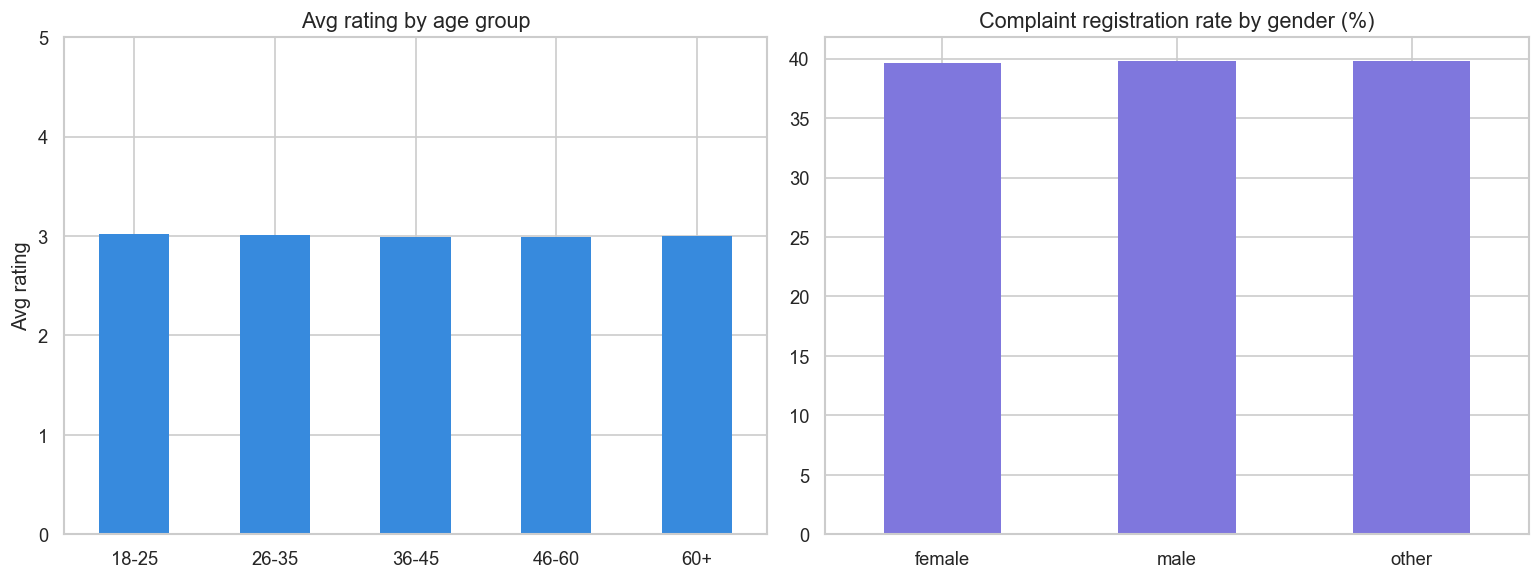

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg rating by age group
age_rating = df.groupby('age_group')['customer_rating'].mean().sort_index()
age_rating.plot(kind='bar', ax=axes[0], color='#378ADD', edgecolor='none')
axes[0].set_title('Avg rating by age group', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg rating')
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=0)

# Complaint rate by gender
gender_complaint = df.groupby('gender')['complaint_registered_bin'].mean() * 100
gender_complaint.plot(kind='bar', ax=axes[1], color='#7F77DD', edgecolor='none')
axes[1].set_title('Complaint registration rate by gender (%)', fontsize=13)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../assets/05_demographics.png', bbox_inches='tight')
plt.show()